In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *
from itertools import product


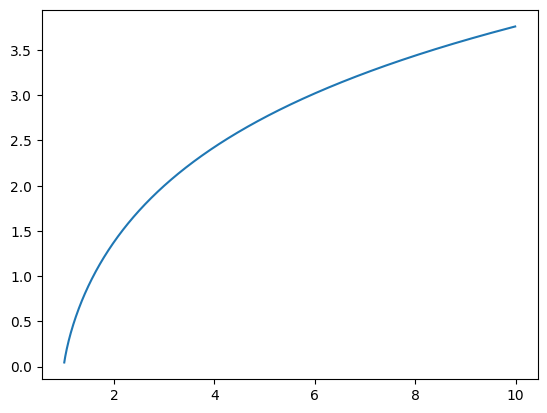

In [2]:
G = lambda X: np.array([g(x) for x in X])

X= np.arange(1.01, 10.0, 0.01)
plt.plot(X, G(X))

# Continuous-variable QKD key rates

In this notebook we are computing the secret key rates for CV-QKD protocols following the calculations in Table III (below) of Zhang et al.'s "_Continuous-variable quantum key distribution system: Past, present, and future_" (2024), __[APR version](https://pubs.aip.org/aip/apr/article/11/1/011318/3279669/Continuous-variable-quantum-key-distribution)__. 

The __[arXiv](https://arxiv.org/pdf/2310.04831)__ version does not have the table but it has an in-text explanation.

NOTE: the $G(x)$ in the table corresponds to the `g(x)` entropy function defined in `qopt_funcs`.

![alt text](zhang_table.png)

In [18]:
V = 10
T_resolution = 0.01
T= np.arange(T_resolution, .99, T_resolution) # extreme values of T cause numerical issues
exc_noise = 0.05
chi = (1 - T)/T + exc_noise
a, b, c = V, T*(V + chi), np.sqrt(T*(V**2 - 1))
Delta = a**2 + b**2 - 2*c**2
D = a*b - c**2
A = (a + b*D + Delta)/(a + 1)
A_prime = (b + a*D + Delta)/(b + 1)
B = D*(b + D)/(a + 1)
B_prime = D*(a + D)/(b + 1)

## Functions for computing the key rate

- Mutual information is the (classical) expression for a bivariate Gaussian distribution, given the covariance matrix.

- Holevo bound depends on the symplectic eigenvalues of the covariance matrix, before and after (= conditioned to) the measurement. 

The expressions of the eigenvalues of the cov. mtx and of the conditional cov. mtx, are taken from Table III (To avoid confusion, the ```lambdas``` are numbered according to Zhang's notation)

All possible combinations of homo-/hetero-dyne measurement, squeezed/coherent states, direct/reverse reconciliation are considered. 

In [19]:
# i know it's a mess, i'm calling global variables inside the functions, as long as it works (for now). i'll oop it eventually

def mutual_information_CV(T, states='squeezed', detection_mode='homodyne'):   # I_AB does NOT depend on the reconc scheme
    if states == 'squeezed' and detection_mode == 'homodyne':
        return 0.5*np.log2(V + chi)/(chi + 1/V)
    elif states == 'coherent' and detection_mode == 'homodyne':
        return 0.5*np.log2((V + chi)/(chi + 1))
    
    elif states == 'squeezed' and detection_mode == 'heterodyne':
        return np.log2(T*(V + chi) + 1)/(T*(chi + 1/V) + 1)
    elif states == 'coherent' and detection_mode == 'heterodyne':
        return np.log2(T*(V + chi) + 1)/(T*(chi + 1) + 1)
    
    else:
        raise ValueError("Invalid \'states\' or \'detection_mode\' argument")


def holevo_bound_CV(T, states='squeezed', detection_mode='homodyne', reconciliation='direct'):

    lambdas = np.zeros((13, len(T)))    # leaving the 1st one empty to use indeces from 1 to 12
    lambdas[0] = T    # to keep track of the transmittance values

    # Alice and Bob's covariance matrix eigenvalues before measurement
    lambdas[1] = np.sqrt(0.5*(Delta + np.sqrt(Delta**2 - 4*D**2)))
    lambdas[2] = np.sqrt(0.5*(Delta - np.sqrt(Delta**2 - 4*D**2)))


    # HOMODYNE measurement

    ## squeezed states
    ### direct reconciliation
    lambdas[3] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
    ### reverse reconciliation
    lambdas[4] = np.sqrt(V*(V*chi + 1)/(chi + V))

    ## coherent states
    ### direct reconciliation
    lambdas[5] = np.sqrt(0.5*(A + np.sqrt(A**2 - 4*B)))
    lambdas[6] = np.sqrt(0.5*(A - np.sqrt(A**2 - 4*B)))
    ### reverse reconciliation
    lambdas[7] = np.sqrt(V*(V*chi + 1)/(chi + V))


    # HETERODYNE measurement

    ## squeezed states
    ### direct reconciliation
    lambdas[8] = np.sqrt(T**2*(V + chi)/(chi + 1/V))
    ### reverse reconciliation
    lambdas[9] = np.sqrt(0.5*(A_prime + np.sqrt(A_prime**2 - 4*B_prime)))
    lambdas[10] = np.sqrt(0.5*(A_prime - np.sqrt(A_prime**2 - 4*B_prime)))

    ## coherent states
    ### direct reconciliation
    lambdas[11] = T*(chi + 1)
    ### reverse reconciliation
    lambdas[12] = (T*(V*chi + 1) + 1)/(T*(V + chi) + 1)

    with np.printoptions(threshold=np.inf):
        print(lambdas)
        
    if states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[3]) 
    elif states == 'squeezed' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[4])
    
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[5]) - g(lambdas[6])
    elif states == 'coherent' and detection_mode == 'homodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[7])
    
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[8]) 
    elif states == 'squeezed' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[9]) - g(lambdas[10])
    
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'direct':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[11])
    elif states == 'coherent' and detection_mode == 'heterodyne' and reconciliation == 'reverse':
        return g(lambdas[1]) + g(lambdas[2]) - g(lambdas[12])
    
    else:
        raise ValueError("Invalid \'states\', \'detection_mode\' or \'reconciliation\' argument")



# NOT WORKING YET --> SYMP EIGVALS LESS THAN 1

coherent homodyne direct
[[0.01       0.02       0.03       0.04       0.05       0.06
  0.07       0.08       0.09       0.1        0.11       0.12
  0.13       0.14       0.15       0.16       0.17       0.18
  0.19       0.2        0.21       0.22       0.23       0.24
  0.25       0.26       0.27       0.28       0.29       0.3
  0.31       0.32       0.33       0.34       0.35       0.36
  0.37       0.38       0.39       0.4        0.41       0.42
  0.43       0.44       0.45       0.46       0.47       0.48
  0.49       0.5        0.51       0.52       0.53       0.54
  0.55       0.56       0.57       0.58       0.59       0.6
  0.61       0.62       0.63       0.64       0.65       0.66
  0.67       0.68       0.69       0.7        0.71       0.72
  0.73       0.74       0.75       0.76       0.77       0.78
  0.79       0.8        0.81       0.82       0.83       0.84
  0.85       0.86       0.87       0.88       0.89       0.9
  0.91       0.92       0.93       0.94       0.

ValueError: Unphysical (less than 1 with tolerance 0.0001) symplectic eigenvalue detected: nu = 0.9812108559498957.

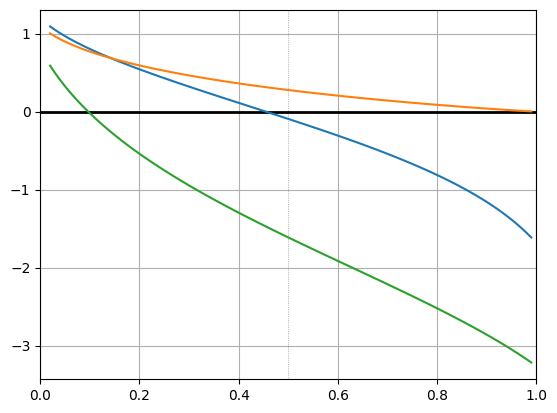

In [23]:
state_class = ['coherent']
det_modes = ['homodyne', 'heterodyne']
reconciliation_modes = ['direct', 'reverse']

from itertools import product

plt.axhline(0, color='black', lw=2)
plt.axvline(0.5, color='black', lw=.5, ls=':', alpha=.5)
plt.grid()
plt.xlim(0, 1)
for states, det_mode, rec_mode in product(state_class, det_modes, reconciliation_modes):
    print(states, det_mode, rec_mode)
    plt.plot(1-T, mutual_information_CV(T, states, det_mode) - holevo_bound_CV(T, states, det_mode, rec_mode), label=f'{states}, {det_mode}, {rec_mode}')
plt.xlabel('Loss $(1 - T)$')
plt.legend()
plt.grid()


# trying to generalize to coherent state protocols

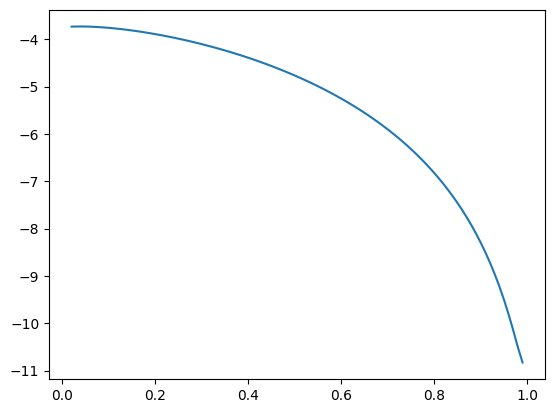

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *
from itertools import product

rates = [CV_keyrate(5, t, exc_noise, alice_detection_mode='homodyne', detection_mode='heterodyne', reconciliation='reverse') for t in T]
plt.plot(1-T, rates)

homodyne homodyne direct
[[11013.2329201      0.          1101.32328747     0.        ]
 [    0.         11013.2329201      0.         -1101.32328747]
 [ 1101.32328747     0.           111.1223292      0.        ]
 [    0.         -1101.32328747     0.           111.1223292 ]]
[[11013.2329201     0.         1557.5063297     0.       ]
 [    0.        11013.2329201     0.        -1557.5063297]
 [ 1557.5063297     0.          221.2446584     0.       ]
 [    0.        -1557.5063297     0.          221.2446584]]
[[11013.2329201      0.          1907.54788946     0.        ]
 [    0.         11013.2329201      0.         -1907.54788946]
 [ 1907.54788946     0.           331.3669876      0.        ]
 [    0.         -1907.54788946     0.           331.3669876 ]]
[[11013.2329201      0.          2202.64657494     0.        ]
 [    0.         11013.2329201      0.         -2202.64657494]
 [ 2202.64657494     0.           441.4893168      0.        ]
 [    0.         -2202.64657494     0.     

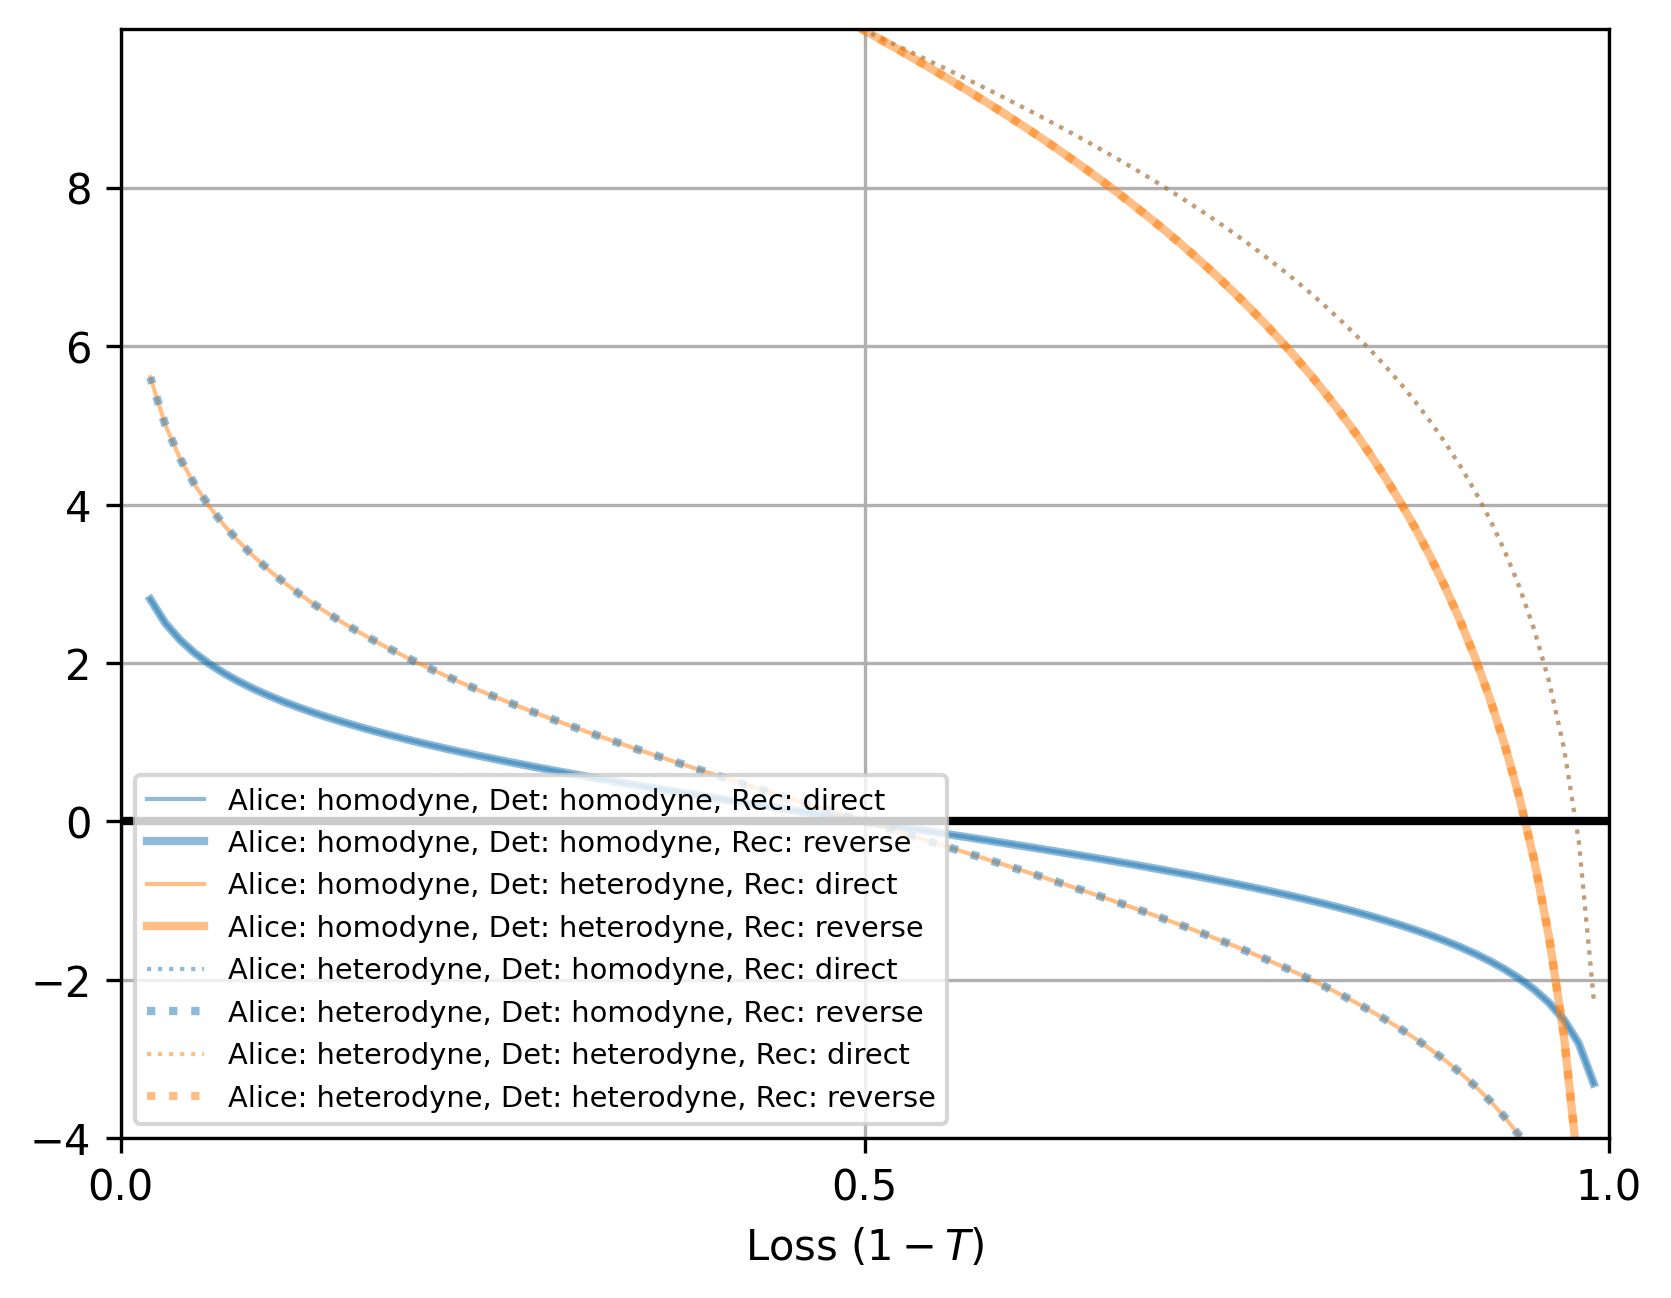

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *
from itertools import product

r_A = 10
# V = np.cosh(r_A)
T_resolution = 0.01
T= np.arange(T_resolution, .99, T_resolution) # extreme values of T cause numerical issues
exc_noise = 0.00

det_modes = ['homodyne', 'heterodyne']
reconciliation_modes = ['direct', 'reverse']
alice_det_modes = ['homodyne', 'heterodyne']

line_styles = {'homodyne': '-', 'heterodyne': ':'}         # linea continua/tratteggiata per Alice
line_widths = {'direct': 1, 'reverse': 2}                  # spessore per reconciliation
colors = {'homodyne': 'tab:blue', 'heterodyne': 'tab:orange'}         # colore per detection

plt.figure(dpi=300)
for a_det, det_mode, rec_mode in product(alice_det_modes, det_modes, reconciliation_modes):
    # Calcolo dei tassi
    print(a_det, det_mode, rec_mode)
    rates = [CV_keyrate_multi_protocol(r_A, t, exc_noise, alice_detection_mode=a_det, bob_detection_mode=det_mode, reconciliation=rec_mode) for t in T]
    
    # Selezione stile
    linestyle = line_styles[a_det]
    linewidth = line_widths[rec_mode]
    color = colors[det_mode]
    
    plt.plot(1-T, rates, linestyle=linestyle, linewidth=linewidth, color=color, alpha=.5, label=f'Alice: {a_det}, Det: {det_mode}, Rec: {rec_mode}')

down, up = -4, 10
plt.xticks(np.arange(0, 1.1, 0.5))
plt.yticks(np.arange(down, up, 2))
plt.ylim(down, up)
plt.xlim(0, 1)
plt.axhline(0, color='black', lw=2)
plt.xlabel('Loss $(1 - T)$')
plt.legend(fontsize='x-small', loc='lower left')
plt.grid()
plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt

alice_detection_mode='heterodyne'
detection_mode='homodyne'
reconciliation='reverse'

T_resolution = 0.01
T= np.arange(T_resolution, .99, T_resolution) # extreme values of T cause numerical issues
f = lambda T: CV_keyrate(r, T, 0, alice_detection_mode=alice_detection_mode, detection_mode=detection_mode, reconciliation=reconciliation)


# parametri
# eps = 0.01
r_values = np.linspace(1, 5, 50)
Tcrit = []

# loop su r_A
for r in r_values:
    Tcrit.append(bisection_solver(f, 1e-6, 1-1e-6))

Tcrit = np.array(Tcrit)

# plot
plt.plot(r_values, Tcrit)
plt.xlabel("r_A")
plt.ylabel("Critical T")
plt.title("Critical channel transmission vs squeezing")
plt.grid(True)
plt.axhline(np.exp(1)**2/(np.exp(1)**2 + 4), color='red', linestyle='--', label='Pure loss limit')

ValueError: Unphysical (less than 1 with tolerance 0.0001) symplectic eigenvalue detected: nu = 0.824027426844874.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qopt_funcs import *
from itertools import product

det_modes = ['homodyne', 'heterodyne']
reconciliation_modes = ['direct', 'reverse']

V = 5
r = np.arccosh(V)
T_A = 1
T = .9
eps = 0.1
gamma = entangling_cloner_covariance_mtx(eps, r, T, T_A)[:4, :4]
print("gamma=\n", gamma)
print(np.array([[T_A*V - T_A + 1, np.sqrt(T_A*T*(V**2 - 1))], [np.sqrt(T_A*T*(V**2 - 1)), T*V + 1-T + eps*T]]))
for det, rec in product(det_modes, reconciliation_modes):
    print(det, rec, "gamma_cond=\n", conditional_cov_mtx(gamma, det, rec))

gamma=
 [[ 5.          0.          4.64758002  0.        ]
 [ 0.          5.          0.         -4.64758002]
 [ 4.64758002  0.          4.69        0.        ]
 [ 0.         -4.64758002  0.          4.69      ]]
[[5.         4.64758002]
 [4.64758002 4.69      ]]
homodyne direct gamma_cond=
 [[0.37 0.  ]
 [0.   4.69]]
homodyne reverse gamma_cond=
 [[0.39445629 0.        ]
 [0.         5.        ]]
heterodyne direct gamma_cond=
 [[1.09 0.  ]
 [0.   1.09]]
heterodyne reverse gamma_cond=
 [[1.20386643 0.        ]
 [0.         1.20386643]]


In [3]:
r_E = rE_noisy(T, eps)
aa = 1-T+eps*T
a = aa/(1-T)
b = np.arccosh(a)
c = np.cosh(b)
d = c*(1-T)
aa, a, b, c, d

(0.19, 1.9000000000000004, 1.2571958266003807, 1.9000000000000004, 0.19)

In [4]:
squeezed_cov(r_E/2)

array([[ 1.9       ,  0.        ,  1.61554944,  0.        ],
       [ 0.        ,  1.9       ,  0.        , -1.61554944],
       [ 1.61554944,  0.        ,  1.9       ,  0.        ],
       [ 0.        , -1.61554944,  0.        ,  1.9       ]])

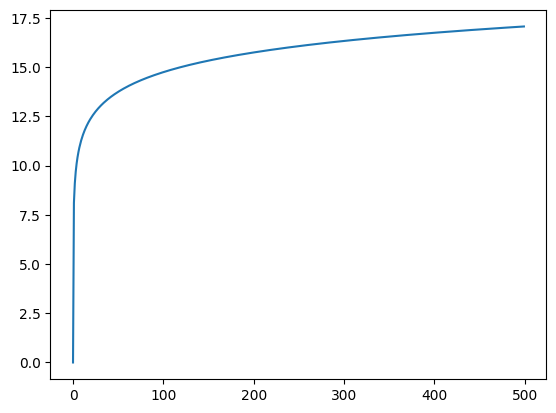

In [12]:

import numpy as np
from qopt_funcs import *
from matplotlib import pyplot as plt
plt.plot(g(np.linspace(0.99999, 101000, 500)))
# g(np.zeros(10))
